# 🛡️ Safe RAG: 금융 문서 임베딩 벡터 역전공격 방어 실험

## 실험 개요
RAG(Retrieval-Augmented Generation) 시스템의 벡터 DB에는 실제 금융 문서의 임베딩이 저장된다.
**Vec2Text** 같은 역전공격(embedding inversion attack)은 이 벡터만으로 원문 텍스트를 상당 수준 복원할 수 있어,
고객 PII(개인식별정보) 유출 위험이 존재한다.

이 노트북은 다음 흐름으로 방어 전략의 효과를 실험한다:

```
금융 문서 생성 → 임베딩 → Vec2Text 역전공격 → PCA/PII 방어 → 재공격 → 트레이드오프 분석
```

| 단계 | 내용 |
|------|------|
| Step 1 | 금융 PII 데이터셋 생성 + 임베딩 + FAISS 인덱스 |
| Step 2 | 원본 벡터 역전공격 (공격 기준선 측정) |
| Step 3 | 정규화 벡터 역전공격 (단순 정규화의 방어 효과 확인) |
| Step 4 | PCA 방어 벡터 역전공격 + RAG 트레이드오프 분석 |
| Step 5 | PII-aware 억제 + PCA 복합 방어 |
| Step 6 | 최적 PCA n_components 탐색 |
| Bonus | 공용 PCA 벡터 배포 Feasibility Check |

## Step 1. 금융 문서 임베딩 벡터 생성

### 목적
공격 실험에 사용할 현실적인 금융 문서 데이터셋을 준비한다.
vec2text 모델이 **영어로 학습**되어 있어, 한국어 문서를 그대로 쓰면 공격 효과가 과소평가된다.
따라서 실제 금융권 문서와 유사한 **영문 PII 포함 문서**를 GPT-4o로 생성한다.

### 환경 설정

### 1-0. 환경 설정

작업 디렉토리 확인, OpenAI API 키 로드, 의존 패키지 설치를 순서대로 수행한다.
`.env` 파일에 `OPENAI_API_KEY`가 설정되어 있어야 하며, GPU 환경(Colab A100)을 권장한다.

In [38]:
# ===== 한국어 vec2text 모델 로드 =====
from transformers import T5ForConditionalGeneration, AutoTokenizer
import torch

model_path = "./vec_to_text_kor/vec2text/saves/ko_vec2text_1536"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 및 토크나이저
korean_model = T5ForConditionalGeneration.from_pretrained(model_path)
korean_tokenizer = AutoTokenizer.from_pretrained(model_path)
korean_model = korean_model.to(device)
korean_model.eval()

# 어댑터
class Vec2TextAdapter(torch.nn.Module):
    def __init__(self, input_dim=1536, output_dim=768):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

adapter = Vec2TextAdapter(1536, 768).to(device)
adapter.load_state_dict(torch.load(f"{model_path}/adapter_1536_to_768.pt"))
adapter.eval()

print("Korean vec2text model loaded successfully!")


Korean vec2text model loaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [39]:
import os
import sys

# 루트 디렉토리 설정 (Colab/Local)
# Colab: /content/drive/MyDrive/Safe_RAG
# Local: ./Safe_RAG 또는 절대경로
try:
    # Colab 환경 감지
    import google.colab
    ROOT_DIR = "/content/drive/MyDrive/Safe_RAG"
except ImportError:
    # 로컬 환경
    ROOT_DIR = r"C:\Users\jjh63\Safe_RAG"

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"파일들이 존재하는지 확인:")
print(f"  - .env: {os.path.exists(os.path.join(ROOT_DIR, '.env'))}")
print(f"  - colab_requirements.txt: {os.path.exists(os.path.join(ROOT_DIR, 'colab_requirements.txt'))}")
print(f"  - output: {os.path.exists(os.path.join(ROOT_DIR, 'output'))}")

ROOT_DIR: C:\Users\jjh63\Safe_RAG
파일들이 존재하는지 확인:
  - .env: True
  - colab_requirements.txt: True
  - output: True


In [40]:
from dotenv import load_dotenv
import os

load_dotenv("/content/drive/MyDrive/Safe_RAG/.env")
api_key = os.getenv("OPENAI_API_KEY")
print(api_key[:10], "...")

sk-proj-5v ...


In [4]:
! cd

c:\Users\jjh63\Safe_RAG


In [5]:
! pip install progressbar

In [6]:
! pip install -r "{ROOT_DIR}/colab_requirements.txt" --quiet --progress-bar on

### 1-2. 문서 로드 및 청크 분할

**목적**: 생성된 금융 문서를 RAG에 적합한 크기로 분할한다.

| 파라미터 | 값 | 이유 |
|----------|-----|------|
| chunk_size | 512 토큰 | Ada-002의 최적 입력 길이 |
| chunk_overlap | 64 토큰 | 문장 경계 정보 손실 방지 |

**인사이트**: 청크가 너무 크면 임베딩이 희석되고, 너무 작으면 맥락이 끊긴다.
512/64 설정은 금융 문서의 단락 구조에 맞게 선택했다.


In [41]:
# output 폴더에서 financial_pii_dataset.jsonl 읽기
dataset_file = "kor_financial_pii_dataset.jsonl" if USE_KOREAN_DATASET else "financial_pii_dataset.jsonl"
output_path = Path(ROOT_DIR) / "output" / dataset_file

if not output_path.exists():
    print(f"Error: {output_path}를 찾을 수 없습니다.")
    print("먼저 llm_synthetic_financial_pii_generator.py를 실행하여 데이터를 생성하세요.")
else:
    # JSONL 파일에서 문서 로드
    documents = []
    with open(output_path, 'r', encoding='utf-8') as f:
        for line in f:
            record = json.loads(line)
            # LangChain Document 형식으로 변환
            doc = Document(
                page_content=record['text'],
                metadata={
                    'doc_id': record['doc_id'],
                    'doc_type': record['doc_type'],
                    'model': record['model']
                }
            )
            documents.append(doc)

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=512,
        chunk_overlap=64,
        separators=["\n\n", "\n", ".", " "]
    )
    chunks = splitter.split_documents(documents)
    print(f"총 청크 수: {len(chunks)}")


총 청크 수: 1000


### 1-3. 임베딩 생성 및 FAISS 인덱스 구축

**목적**: 각 청크를 `text-embedding-ada-002`로 1536차원 벡터로 변환하고,
FAISS `IndexFlatIP`(내적 기반 유사도)로 저장한다.

- `embeddings_unsafe_raw.npy`: 원본 벡터 (공격 실험용)
- `faiss_unsafe.index`: 정규화 벡터 인덱스 (RAG 검색용)

**인사이트**: FAISS는 내부 저장 시 L2 정규화를 적용하므로,
원본 벡터와 FAISS 내부 벡터는 크기(magnitude)만 다르고 방향은 동일하다.
역전공격 실험에서는 이 두 버전을 분리해 비교한다.

In [29]:
from openai import OpenAI
client = OpenAI()
for m in client.models.list():
    print(m.id)


text-embedding-ada-002
text-embedding-3-small
gpt-4o-mini
omni-moderation-latest
o4-mini
gpt-4.1-mini


In [45]:
import numpy as np
import faiss
from tqdm import tqdm
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
client = OpenAI()

def get_embedding(text: str) -> np.ndarray:
    response = client.embeddings.create(
        model="text-embedding-ada-002",
        input=text
    )
    return np.array(response.data[0].embedding, dtype=np.float32)

def build_and_save_index(chunks, index_path: str, raw_path: str):
    embeddings_list = []
    for chunk in tqdm(chunks, desc=f"임베딩 생성"):
        embeddings_list.append(get_embedding(chunk.page_content))

    embeddings_raw = np.vstack(embeddings_list)

    np.save(raw_path, embeddings_raw)
    print(f"원본 벡터 저장: {raw_path} | shape: {embeddings_raw.shape}")

    embeddings_norm = embeddings_raw.copy()
    faiss.normalize_L2(embeddings_norm)
    index = faiss.IndexFlatIP(1536)
    index.add(embeddings_norm)
    faiss.write_index(index, index_path)
    print(f"FAISS 인덱스 저장: {index_path} | {index.ntotal}개 벡터")

    return embeddings_raw

embeddings_raw = build_and_save_index(
      chunks,
      index_path=os.path.join(ROOT_DIR, "faiss_unsafe.index"),
      raw_path=os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy")
  )

임베딩 생성: 100%|██████████| 1000/1000 [06:29<00:00,  2.57it/s]

원본 벡터 저장: C:\Users\jjh63\Safe_RAG\embeddings_unsafe_raw.npy | shape: (1000, 1536)
FAISS 인덱스 저장: C:\Users\jjh63\Safe_RAG\faiss_unsafe.index | 1000개 벡터


### 1-4. RAG 기본 성능 측정 (Recall@K)

**목적**: 방어 적용 전 기준 RAG 성능을 먼저 측정한다.
이후 방어를 적용했을 때 성능 저하를 이 값과 비교한다.

**Recall@K**: 특정 청크를 쿼리로 넣었을 때 동일 청크가 상위 K개 결과 안에 나오는 비율.
이상적인 RAG 인덱스라면 Recall@5 = 100%가 되어야 한다.

In [46]:
import numpy as np
import faiss
from tqdm import tqdm
from dotenv import load_dotenv
from openai import OpenAI

def get_embedding(text: str) -> np.ndarray:
    response = client.embeddings.create(
        model="text-embedding-ada-002",
        input=text
    )
    return np.array(response.data[0].embedding, dtype=np.float32)

In [47]:
def recall_at_k(index_path, chunks, k=5, n_eval=20):
    index = faiss.read_index(index_path)
    hits = 0
    for i in range(min(n_eval, len(chunks))):
        vec = get_embedding(chunks[i].page_content).reshape(1, -1)
        faiss.normalize_L2(vec)
        _, indices = index.search(vec, k)
        if i in indices[0]:
            hits += 1
    score = hits / min(n_eval, len(chunks))
    print(f"Recall@{k} ({index_path}): {score:.2f}")
    return score

recall_at_k(os.path.join(ROOT_DIR, "faiss_unsafe.index"), chunks)
# 목표: 0.90 이상

Recall@5 (C:\Users\jjh63\Safe_RAG\faiss_unsafe.index): 1.00


1.0

### 1-5. FAISS 인덱스에서 정규화 벡터 추출

**목적**: FAISS에 저장된 L2 정규화 벡터를 numpy 배열로 복원한다.
`index.reconstruct_n()`은 FAISS 인덱스 내부의 벡터를 직접 읽어오는 함수다.

**인사이트**: 이 벡터는 원본과 방향이 동일하지만 크기가 1로 고정되어 있다.
Step 3에서 '정규화만으로 방어가 되는가'를 검증하기 위해 별도로 추출한다.

In [48]:
import faiss
import numpy as np

index = faiss.read_index(os.path.join(ROOT_DIR, "faiss_unsafe.index"))
n = index.ntotal
dim = index.d

embeddings_norm = np.zeros((n, dim), dtype=np.float32)
index.reconstruct_n(0, n, embeddings_norm)

print(f"추출된 정규화 벡터: {embeddings_norm.shape}")

추출된 정규화 벡터: (1000, 1536)


### 1-6. 임베딩 유틸 함수 재정의

이후 단계에서 새로운 텍스트(예: 쿼리, PII 샘플)를 임베딩할 때 사용하는 공통 함수.
모델은 전 단계와 동일한 `text-embedding-ada-002`를 유지한다.

In [49]:
from openai import OpenAI
import numpy as np

client = OpenAI()  # OPENAI_API_KEY 환경변수 필요

def get_embedding(text: str) -> np.ndarray:
    response = client.embeddings.create(
        model="text-embedding-ada-002",
        input=text
    )
    return np.array(response.data[0].embedding, dtype=np.float32)

### 1-7. PCA 방어 벡터 생성 (1차 시도, n=128)

**목적**: 원본 1536차원 벡터를 128차원으로 압축 후 역투영(reconstruct)한다.
이 과정에서 하위 주성분 정보가 손실되며, 역전공격 모델이 복원에 필요한 세부 패턴이 제거된다.

**원리**:
```
원본 (1536d) → PCA 압축 (128d) → 역투영 (1536d) → 방어 벡터
```
차원은 원본과 동일하게 유지되므로 FAISS 인덱스 구조를 그대로 사용할 수 있다.

**인사이트**: n=128은 1536의 약 8% 수준으로, 상당한 정보 손실이 발생한다.
방어력은 높겠지만 RAG 검색 품질 저하도 클 수 있다. Step 4에서 검증한다.

In [50]:
from sklearn.decomposition import PCA
import torch
import numpy as np

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
print(f"원본 벡터 shape: {embeddings_raw.shape}")

embeddings_matrix = embeddings_raw.astype(np.float32)
n_samples, n_features = embeddings_matrix.shape

n_components = min(128, n_samples - 1)
print(f"PCA 설정: {n_features}d → {n_components}d → {n_features}d")

pca = PCA(n_components=n_components, svd_solver='full')
pca.fit(embeddings_matrix)

compressed    = pca.transform(embeddings_matrix)
reconstructed = pca.inverse_transform(compressed).astype(np.float32)

np.save(os.path.join(ROOT_DIR, "embeddings_defense_pca.npy"), reconstructed)

retained = pca.explained_variance_ratio_.sum()
print(f"PCA 방어 벡터 저장 완료")
print(f"보존된 분산: {retained:.1%}")

원본 벡터 shape: (1000, 1536)
PCA 설정: 1536d → 128d → 1536d
PCA 방어 벡터 저장 완료
보존된 분산: 86.6%


## Step 2. 원본 벡터로 Vec2Text 역전공격

### 목적
`text-embedding-ada-002`가 생성한 **원본 1536차원 벡터**에 직접 Vec2Text를 적용한다.
이 결과가 **공격 기준선(baseline)**이 된다.

### 측정 지표
- **ROUGE-1 F1**: 복원된 텍스트와 원문의 단어 겹침 비율. 높을수록 공격 성공.

### 예상
정보 손실 없는 원본 벡터이므로 ROUGE가 가장 높게 나올 것.

In [51]:
import transformers, accelerate
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)


transformers: 4.44.2
accelerate: 0.34.2


In [37]:
! pip install --upgrade pip
! pip install resource

     ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
     ------------------------ --------------- 1.1/1.8 MB 23.5 MB/s eta 0:00:01
     ---------------------------------------- 1.8/1.8 MB 23.1 MB/s eta 0:00:00


ERROR: To modify pip, please run the following command:
C:\Users\jjh63\Safe_RAG\safeRag\Scripts\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
import vec2text
import torch
import numpy as np
from tqdm import tqdm
from rouge_score import rouge_scorer

# ===== 한국어 vec2text 모델 =====
from transformers import T5ForConditionalGeneration, AutoTokenizer

model_path = "./vec_to_text_kor/vec2text/saves/ko_vec2text_1536"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 로드
korean_model = T5ForConditionalGeneration.from_pretrained(model_path)
korean_tokenizer = AutoTokenizer.from_pretrained(model_path)
korean_model = korean_model.to(device)
korean_model.eval()

# 어댑터
class Vec2TextAdapter(torch.nn.Module):
    def __init__(self, input_dim=1536, output_dim=768):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

adapter = Vec2TextAdapter(1536, 768).to(device)
adapter.load_state_dict(torch.load(f"{model_path}/adapter_1536_to_768.pt"))
adapter.eval()

print("한국어 vec2text 모델 로드 완료")
print(f"- 모델: {model_path}")
print(f"- 디바이스: {device}")
print()

# ===== 임베딩으로부터 텍스트 복원 =====
rouge = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=False)
hypotheses_raw = []

print("원본 벡터 역전공격 진행 중...")
for i, embedding in enumerate(tqdm(embeddings_raw[:10], desc="원본 벡터 역전공격")):
    try:
        # 1536→768 변환
        embedding_tensor = torch.from_numpy(embedding).to(device).unsqueeze(0)
        with torch.no_grad():
            embedding_768 = adapter(embedding_tensor)
        
        # 텍스트 생성
        with torch.no_grad():
            input_ids = korean_tokenizer.encode("", return_tensors="pt").to(device)
            outputs = korean_model.generate(
                input_ids,
                max_length=256,
                num_beams=1,
                do_sample=False
            )
        
        restored_text = korean_tokenizer.decode(outputs[0], skip_special_tokens=True)
        hypotheses_raw.append(restored_text)
        
        # 원본과 비교 (Document 객체 처리)
        if i < 3:
            # Document 객체에서 텍스트 추출
            chunk = chunks[i]
            if hasattr(chunk, 'page_content'):
                original = chunk.page_content
            else:
                original = str(chunk)
            
            score = rouge.score(original[:100], restored_text)['rouge1'].fmeasure
            print(f"[청크 {i}] ROUGE-1: {score:.3f}")
            print(f"  원본: {original[:60]}...")
            print(f"  복원: {restored_text[:60]}...")
    
    except Exception as e:
        print(f"  오류: {str(e)[:80]}")
        hypotheses_raw.append("")

print()
print(f"✓ 복원 완료: {len(hypotheses_raw)}개 청크")


한국어 vec2text 모델 로드 완료
- 모델: ./vec_to_text_kor/vec2text/saves/ko_vec2text_1536
- 디바이스: cuda

원본 벡터 역전공격 진행 중...


원본 벡터 역전공격:  10%|█         | 1/10 [00:01<00:15,  1.76s/it]

[청크 0] ROUGE-1: 0.000
  원본: 거래명세서 문서입니다.
Gary Miles: 120606753
ywatson@example.org...
  복원:                                                         ...


원본 벡터 역전공격:  20%|██        | 2/10 [00:03<00:14,  1.75s/it]

[청크 1] ROUGE-1: 0.000
  원본: 거래명세서 문서입니다.
Christine Harris: 479251675
fhaas@example.org...
  복원:                                                         ...


원본 벡터 역전공격:  30%|███       | 3/10 [00:05<00:12,  1.75s/it]

[청크 2] ROUGE-1: 0.000
  원본: 은행 상담원: 안녕하세요. Antonio Nguyen님, 어떻게 도와드릴까요?

고객: 제 계좌에 접근할 수...
  복원:                                                         ...


원본 벡터 역전공격: 100%|██████████| 10/10 [00:17<00:00,  1.73s/it]


✓ 복원 완료: 10개 청크


## Step 3. 정규화 벡터로 Vec2Text 역전공격

### 목적
FAISS는 내부적으로 벡터를 L2 정규화한다. 정규화 자체가 방어 효과를 갖는지 확인한다.

### 인사이트 (가설)
정규화는 벡터의 **방향**은 유지하고 크기만 제거하므로,
의미 정보는 그대로 남아 있어 방어 효과가 거의 없을 것으로 예상한다.
→ 만약 ROUGE가 원본과 비슷하게 나온다면, **정규화만으로는 충분하지 않음**을 의미.

In [14]:
# ===== 한국어 vec2text 모델 로드 =====
from transformers import T5ForConditionalGeneration, AutoTokenizer
import torch

model_path = "./vec_to_text_kor/vec2text/saves/ko_vec2text_1536"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 및 토크나이저
korean_model = T5ForConditionalGeneration.from_pretrained(model_path)
korean_tokenizer = AutoTokenizer.from_pretrained(model_path)
korean_model = korean_model.to(device)
korean_model.eval()

# 어댑터
class Vec2TextAdapter(torch.nn.Module):
    def __init__(self, input_dim=1536, output_dim=768):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

adapter = Vec2TextAdapter(1536, 768).to(device)
adapter.load_state_dict(torch.load(f"{model_path}/adapter_1536_to_768.pt"))
adapter.eval()

print("Korean vec2text model loaded successfully!")


사용 디바이스: cuda


역전공격 진행:  10%|█         | 1/10 [00:30<04:37, 30.83s/it]


[청크 0] ROUGE-1: 0.091
  원본: Philip Martin  
08455 Meagan Groves  
Deborahshire, MH 37582...
  복원: Martin Philips Bank, Countryside Bank, Capital One, Branch  ...


역전공격 진행:  20%|██        | 2/10 [01:00<04:00, 30.06s/it]


[청크 1] ROUGE-1: 0.382
  원본: Please process the closure at your earliest convenience and ...
  복원: Please proceed to the earliest possible disposal of the fund...


...


[청크 7] ROUGE-1: 0.184
  원본: Subject: Urgent: Disputed International Wire Transfer Notifi...
  복원: Subject: âWe Need to Ensure Your Account is Deferred to a Gl...


역전공격 진행:  90%|█████████ | 9/10 [03:32<00:23, 23.26s/it]


[청크 8] ROUGE-1: 0.930
  원본: Because you have not previously authorized this transaction,...
  복원: Because you have not previously authorized this transaction,...


역전공격 진행: 100%|██████████| 10/10 [03:52<00:00, 23.28s/it]


[청크 9] ROUGE-1: 0.603
  원본: Please contact our Fraud Department as soon as possible at +...
  복원: Please notify our Fraud Department as soon as possible at +1...

평균 ROUGE-1 (Unsafe 베이스라인): 0.497
최고: 0.930 | 최저: 0.091
→ 이 숫자가 높을수록 역전공격 성공, 낮을수록 자체 방어력 있음


## Step 4-A. PCA 방어 벡터의 역전공격 방어 성능 측정

### 목적
128차원으로 압축 후 역투영(reconstruct)한 PCA 방어 벡터가 Vec2Text 공격을 얼마나 막는지 측정한다.

### 원리
PCA 재구성은 하위 주성분(노이즈 성분)을 버리는 효과가 있어,
역전공격 모델이 의존하는 세밀한 텍스트 패턴 정보가 손상된다.

### 인사이트 (가설)
압축률이 높을수록 (n_components가 작을수록) 방어력은 강해지지만,
RAG 검색 품질도 함께 저하되는 **트레이드오프**가 존재할 것.

In [16]:
# ===== 한국어 vec2text 모델 로드 =====
from transformers import T5ForConditionalGeneration, AutoTokenizer
import torch

model_path = "./vec_to_text_kor/vec2text/saves/ko_vec2text_1536"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 및 토크나이저
korean_model = T5ForConditionalGeneration.from_pretrained(model_path)
korean_tokenizer = AutoTokenizer.from_pretrained(model_path)
korean_model = korean_model.to(device)
korean_model.eval()

# 어댑터
class Vec2TextAdapter(torch.nn.Module):
    def __init__(self, input_dim=1536, output_dim=768):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

adapter = Vec2TextAdapter(1536, 768).to(device)
adapter.load_state_dict(torch.load(f"{model_path}/adapter_1536_to_768.pt"))
adapter.eval()

print("Korean vec2text model loaded successfully!")


사용 디바이스: cuda
PCA 방어 벡터 shape: (4640, 1536)


PCA 방어 벡터 역전공격:  10%|█         | 1/10 [00:33<04:58, 33.19s/it]


[청크 0] ROUGE-1: 0.466
  원본: Philip Martin  
08455 Meagan Groves  
Deborahshire, MH 37582...
  복원: Martin Phillips Bank, FSB.  April 27, 2017  Dear Sir, I am w...


PCA 방어 벡터 역전공격:  20%|██        | 2/10 [00:59<03:50, 28.87s/it]


[청크 1] ROUGE-1: 0.466
  원본: Please process the closure at your earliest convenience and ...
  복원: Please proceed to the following to close your account. The r...


...


[청크 7] ROUGE-1: 0.327
  원본: Subject: Urgent: Disputed International Wire Transfer Notifi...
  복원: Dear Gary, We sent you the following notice regarding a rece...


PCA 방어 벡터 역전공격:  90%|█████████ | 9/10 [03:30<00:22, 22.86s/it]


[청크 8] ROUGE-1: 0.511
  원본: Because you have not previously authorized this transaction,...
  복원: We recognize that you did not authorize this transaction. To...


PCA 방어 벡터 역전공격: 100%|██████████| 10/10 [03:54<00:00, 23.42s/it]


[청크 9] ROUGE-1: 0.432
  원본: Please contact our Fraud Department as soon as possible at +...
  복원: To protect your security, please notify us immediately at 88...

평균 ROUGE-1 (PCA 방어 벡터): 0.482
최고: 1.000 | 최저: 0.327


## Step 4-B. RAG 검색 정확성 vs 방어 성능 트레이드오프 분석

### 목적
방어가 강해질수록 RAG 성능이 얼마나 희생되는지 정량화한다.
실용적인 Safe RAG의 배포 기준을 도출한다.

### 평가 기준
| 지표 | 의미 | 목표 |
|------|------|------|
| Recall@5 | 정답 청크가 상위 5개 안에 있을 확률 | ≥ 90% |
| ROUGE-1 감소율 | 공격 성공률이 얼마나 줄었는가 | > 20% |

### 인사이트
두 지표를 동시에 만족하는 n_components 값을 찾는 것이 핵심이다.
이 분석 결과가 Step 6(최적 PCA 탐색)의 기준이 된다.

In [18]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import pandas as pd

print("="*80)
print("📊 최종 트레이드오프 분석: RAG 정확성 vs 벡터 보안")
print("="*80)

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
embeddings_pca = np.load(os.path.join(ROOT_DIR, "embeddings_defense_pca.npy"))

attack_results = {
    "원본 벡터": {
        "rouge_mean": np.mean(scores_raw),
        "rouge_std": np.std(scores_raw),
        "rouge_max": max(scores_raw),
        "rouge_min": min(scores_raw)
    },
    "정규화 벡터": {
        "rouge_mean": np.mean(scores_norm),
        "rouge_std": np.std(scores_norm),
        "rouge_max": max(scores_norm),
        "rouge_min": min(scores_norm)
    },
    "PCA 방어 벡터": {
        "rouge_mean": np.mean(scores_pca),
        "rouge_std": np.std(scores_pca),
        "rouge_max": max(scores_pca),
        "rouge_min": min(scores_pca)
    }
}

print("\n🔴 벡터 역전공격 성공도 (ROUGE-1):")
print("-" * 80)
for name, metrics in attack_results.items():
    print(f"{name:20} | 평균: {metrics['rouge_mean']:.3f} ± {metrics['rouge_std']:.3f} | 범위: [{metrics['rouge_min']:.3f}, {metrics['rouge_max']:.3f}]")

def evaluate_rag_recall(embeddings, name, chunks, k=5, n_eval=50):
    n_samples = min(n_eval, len(chunks))
    embeddings_eval = embeddings.copy()
    faiss.normalize_L2(embeddings_eval)
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings_eval)

    hits = 0
    retrieval_scores = []

    for i in range(n_samples):
        vec = embeddings[i:i+1].copy()
        faiss.normalize_L2(vec)
        distances, indices = index.search(vec, k)

        if i in indices[0]:
            hits += 1
        retrieval_scores.append(distances[0][0])

    recall_at_k = hits / n_samples
    avg_relevance = np.mean(retrieval_scores)

    return {"recall_at_k": recall_at_k, "avg_relevance": avg_relevance}

rag_results = {}
print("\n🟢 RAG 검색 정확성 (Recall@5):")
print("-" * 80)

for embeddings, name in [
    (embeddings_raw, "원본 벡터"),
    (embeddings_pca, "PCA 방어 벡터")
]:
    result = evaluate_rag_recall(embeddings, name, chunks, k=5, n_eval=50)
    rag_results[name] = result
    print(f"{name:20} | Recall@5: {result['recall_at_k']:.1%} | 평균 관련성: {result['avg_relevance']:.4f}")

print("\n" + "="*80)
print("⚖️  트레이드오프 종합 분석")
print("="*80)

raw_attack = attack_results["원본 벡터"]["rouge_mean"]
pca_attack = attack_results["PCA 방어 벡터"]["rouge_mean"]
attack_reduction = (raw_attack - pca_attack) / raw_attack * 100

raw_recall = rag_results["원본 벡터"]["recall_at_k"]
pca_recall = rag_results["PCA 방어 벡터"]["recall_at_k"]
recall_loss = (raw_recall - pca_recall) / raw_recall * 100

print(f"\n공격 성공률 감소:")
print(f"  → 원본: {raw_attack:.3f} → PCA: {pca_attack:.3f}")
print(f"  → 감소율: {attack_reduction:.1f}%")

print(f"\nRAG 검색 정확성 손실:")
print(f"  → 원본: {raw_recall:.1%} → PCA: {pca_recall:.1%}")
print(f"  → 손실율: {recall_loss:.1f}%")

print(f"\n📈 효율성 지수 (낮을수록 좋음):")
efficiency = attack_reduction / max(recall_loss, 1)
print(f"  → 방어효과 / RAG손실 = {efficiency:.2f}")

print("\n" + "="*80)
if pca_recall >= 0.90 and attack_reduction > 20:
    print("✅ 최적 트레이드오프 달성")
    print(f"   - RAG 성능 유지: {pca_recall:.1%} (목표: 90% 이상)")
    print(f"   - 공격 방어력: {attack_reduction:.1f}% 감소 (좋음)")
elif pca_recall >= 0.90:
    print("⚠️  RAG 성능은 충분하나 방어력 개선 필요")
    print(f"   - 현재: {pca_recall:.1%}, 현재 공격 감소: {attack_reduction:.1f}%")
    print(f"   💡 제안: n_components를 더 줄여 방어력 강화")
else:
    print("⚠️  RAG 성능 목표 미달")
    print(f"   - 현재: {pca_recall:.1%}, 목표: 90% 이상")
    print(f"   💡 제안: n_components를 증가시켜 성능 복구")
print("="*80)

📊 최종 트레이드오프 분석: RAG 정확성 vs 벡터 보안

🔴 벡터 역전공격 성공도 (ROUGE-1):
--------------------------------------------------------------------------------
원본 벡터                | 평균: 0.523 ± 0.202 | 범위: [0.094, 0.932]
정규화 벡터               | 평균: 0.497 ± 0.254 | 범위: [0.091, 0.930]
PCA 방어 벡터            | 평균: 0.482 ± 0.179 | 범위: [0.327, 1.000]

🟢 RAG 검색 정확성 (Recall@5):
--------------------------------------------------------------------------------
원본 벡터                | Recall@5: 100.0% | 평균 관련성: 1.0000
PCA 방어 벡터            | Recall@5: 100.0% | 평균 관련성: 1.0000

⚖️  트레이드오프 종합 분석

공격 성공률 감소:
  → 원본: 0.523 → PCA: 0.482
  → 감소율: 7.8%

RAG 검색 정확성 손실:
  → 원본: 100.0% → PCA: 100.0%
  → 손실율: 0.0%

📈 효율성 지수 (낮을수록 좋음):
  → 방어효과 / RAG손실 = 7.76

⚠️  RAG 성능은 충분하나 방어력 개선 필요
   - 현재: 100.0%, 현재 공격 감소: 7.8%
   💡 제안: n_components를 더 줄여 방어력 강화


## Step 5. PII-Aware 억제 + PCA 복합 방어 (고도화)

### 목적
기존 PCA 단독 방어의 한계를 극복하기 위해 **PII 신호 집중 차원을 먼저 억제**한 뒤 PCA를 적용하는 복합 방어를 구성한다.

### 고도화 포인트 (_m4_ 대비 개선)

| 항목 | 기존 | 고도화 |
|------|------|--------|
| PII 탐지 | 키워드 단순 매칭 | **밀도 스코어링** (청크 내 키워드 비율) |
| 억제 방식 | 하드 제거 (→ 0) | **소프트 억제** (신호 크기 비례 감쇠) |
| 억제 강도 | n_suppress 고정(200) | **alpha 파라미터화** (0~1 연속 조정) |
| 최적화 | 없음 | **n_suppress × n_components 2D 그리드 서치** |

In [20]:
import numpy as np
from sklearn.decomposition import PCA

# ── PII 키워드 사전 (금융 도메인 확장) ────────────────────────────────────────
PII_KEYWORDS = [
    # 신원 정보
    'SSN', 'social security', 'date of birth', 'passport', 'driver license',
    'full name', 'first name', 'last name',
    # 금융 계좌
    'account number', 'account', 'routing number', 'IBAN', 'swift',
    'credit card', 'card number', 'CVV', 'expiry',
    # 거래 정보
    'transaction', 'payment', 'transfer', 'wire', 'deposit', 'withdrawal',
    # 대출/보험
    'loan', 'mortgage', 'policy', 'premium', 'claim', 'beneficiary',
    # 급여/자산
    'salary', 'income', 'net worth', 'balance', 'portfolio',
    # 부정거래
    'fraud', 'suspicious', 'alert', 'flagged',
    # 연락처
    'address', 'phone', 'email', 'zip code',
]

def pii_density_score(text: str) -> float:
    """청크 내 PII 키워드 밀도 계산 (키워드 수 / 총 단어 수)"""
    words = text.lower().split()
    if not words:
        return 0.0
    hits = sum(1 for kw in PII_KEYWORDS if kw.lower() in text.lower())
    return hits / len(words)

def defend_pii_soft(
    matrix: np.ndarray,
    pii_samples: np.ndarray,
    n_suppress: int = 200,
    alpha: float = 0.85,
) -> np.ndarray:
    """
    고도화된 PII-Aware 소프트 억제.

    기존: 상위 n_suppress 차원을 0으로 하드 제거
    고도화: 각 차원의 PII 신호 크기에 비례해 감쇠
      suppression_weight[d] = alpha * (pii_signal[d] / pii_signal.max())
      defended[:, d] *= (1 - suppression_weight[d])

    Args:
        matrix      : 전체 임베딩 (N, D)
        pii_samples : PII 밀도가 높은 청크의 임베딩
        n_suppress  : 억제 대상 차원 수
        alpha       : 최대 억제 강도 (0=억제 없음, 1=완전 제거)
    """
    pii_mean    = pii_samples.mean(axis=0)   # (D,)
    corpus_mean = matrix.mean(axis=0)        # (D,)
    pii_signal  = np.abs(pii_mean - corpus_mean)  # PII 집중 신호

    suppress_dims = np.argsort(pii_signal)[-n_suppress:]

    # 소프트 억제: 신호 크기 비례 감쇠
    signal_in_dims = pii_signal[suppress_dims]
    weight = alpha * (signal_in_dims / signal_in_dims.max())

    defended = matrix.copy()
    defended[:, suppress_dims] *= (1.0 - weight)  # 비례 감쇠

    norms    = np.linalg.norm(defended, axis=1, keepdims=True)
    defended = (defended / norms).astype(np.float32)
    return defended

# ── PII 밀도 스코어링으로 샘플 선별 ──────────────────────────────────────────
embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))

density_scores = np.array([pii_density_score(c.page_content) for c in chunks])
threshold      = np.percentile(density_scores, 70)  # 상위 30%를 PII 청크로 간주
pii_chunk_idx  = np.where(density_scores >= threshold)[0]

pii_samples = embeddings_raw[pii_chunk_idx]
print(f'PII 밀도 임계값 : {threshold:.4f}')
print(f'PII 고밀도 청크 : {len(pii_chunk_idx)}개 ({len(pii_chunk_idx)/len(chunks):.1%})')
print(f'평균 PII 밀도   : {density_scores.mean():.4f}  최고: {density_scores.max():.4f}')

# 기본 파라미터로 방어 벡터 생성
N_SUPPRESS = 200
ALPHA      = 0.85

embeddings_pii_defended = defend_pii_soft(
    embeddings_raw, pii_samples, n_suppress=N_SUPPRESS, alpha=ALPHA
)
np.save(os.path.join(ROOT_DIR, "embeddings_defense_pii.npy"), embeddings_pii_defended)
print(f'\nPII 소프트 억제 완료 (n_suppress={N_SUPPRESS}, alpha={ALPHA})')
print(f'방어 벡터 shape: {embeddings_pii_defended.shape}')


PII 밀도 임계값 : 0.0789
PII 고밀도 청크 : 1403개 (30.2%)
평균 PII 밀도   : 0.0655  최고: 0.5000

PII 소프트 억제 완료 (n_suppress=200, alpha=0.85)
방어 벡터 shape: (4640, 1536)


### 5-2. PII 억제 + PCA 복합 방어 벡터 생성

PII 소프트 억제로 민감 차원을 감쇠한 뒤, PCA 재구성으로 잔여 노이즈까지 제거한다.
두 변환이 **독립적인 정보 채널**을 공략하므로 방어 효과가 상보적으로 작용한다.

```
원본 (1536d)
  → PII 소프트 억제 (PII 신호 차원 감쇠)
  → PCA 재구성 (하위 주성분 제거)
  → L2 정규화
  → 방어 벡터 (1536d)
```

In [21]:
from sklearn.decomposition import PCA
import numpy as np

embeddings_pii_defended = np.load(os.path.join(ROOT_DIR, "embeddings_defense_pii.npy"))
n_samples, n_features   = embeddings_pii_defended.shape
n_components            = min(128, n_samples - 1)

print(f'PCA 적용: {n_features}d → {n_components}d → {n_features}d')

pca_combined = PCA(n_components=n_components, svd_solver='full')
pca_combined.fit(embeddings_pii_defended)

compressed    = pca_combined.transform(embeddings_pii_defended)
reconstructed = pca_combined.inverse_transform(compressed).astype(np.float32)

norms                = np.linalg.norm(reconstructed, axis=1, keepdims=True)
embeddings_combined  = (reconstructed / norms).astype(np.float32)

np.save(os.path.join(ROOT_DIR, "embeddings_defense_combined.npy"), embeddings_combined)
retained = pca_combined.explained_variance_ratio_.sum()
print(f'분산 보존율: {retained:.1%}')
print(f'복합 방어 벡터 저장 완료: {embeddings_combined.shape}')


PCA 적용: 1536d → 128d → 1536d
분산 보존율: 77.3%
복합 방어 벡터 저장 완료: (4640, 1536)


### 5-3. 복합 방어 벡터(PCA+PII)에 Vec2Text 역전공격

**목적**: PII-Aware 억제 + PCA 복합 방어가 단일 방어보다 얼마나 더 효과적인지 측정한다.

**비교 대상**: 원본, PCA 단독, PII 단독, PCA+PII 복합
→ 복합 방어가 각 단독 방어의 효과를 단순 합산 이상으로 넘는지 확인한다.

In [23]:
# ===== 한국어 vec2text 모델 로드 =====
from transformers import T5ForConditionalGeneration, AutoTokenizer
import torch

model_path = "./vec_to_text_kor/vec2text/saves/ko_vec2text_1536"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 및 토크나이저
korean_model = T5ForConditionalGeneration.from_pretrained(model_path)
korean_tokenizer = AutoTokenizer.from_pretrained(model_path)
korean_model = korean_model.to(device)
korean_model.eval()

# 어댑터
class Vec2TextAdapter(torch.nn.Module):
    def __init__(self, input_dim=1536, output_dim=768):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

adapter = Vec2TextAdapter(1536, 768).to(device)
adapter.load_state_dict(torch.load(f"{model_path}/adapter_1536_to_768.pt"))
adapter.eval()

print("Korean vec2text model loaded successfully!")


[강화 복합 방어 벡터 생성 완료]
  소프트 억제      : n_suppress=256, alpha=0.92
  PII 방향 제거    : 5개 subspace
  PCA 복원         : 1536d → 128d → 1536d (분산 71.4%)
  타깃 노이즈      : 상위 150차원, σ=0.012
  방어 벡터 shape  : (4640, 1536)
  PII 방향 잔존 에너지(평균 L2): 0.0096  ← 0에 가까울수록 PII 단서 제거 양호

💾 생성 메타데이터 저장 완료: C:\Users\jjh63\Safe_RAG\embeddings_defense_combined_meta.json


In [25]:
# ===== 한국어 vec2text 모델 로드 =====
from transformers import T5ForConditionalGeneration, AutoTokenizer
import torch

model_path = "./vec_to_text_kor/vec2text/saves/ko_vec2text_1536"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 및 토크나이저
korean_model = T5ForConditionalGeneration.from_pretrained(model_path)
korean_tokenizer = AutoTokenizer.from_pretrained(model_path)
korean_model = korean_model.to(device)
korean_model.eval()

# 어댑터
class Vec2TextAdapter(torch.nn.Module):
    def __init__(self, input_dim=1536, output_dim=768):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

adapter = Vec2TextAdapter(1536, 768).to(device)
adapter.load_state_dict(torch.load(f"{model_path}/adapter_1536_to_768.pt"))
adapter.eval()

print("Korean vec2text model loaded successfully!")


[Step 5-3] PCA+PII 복합 방어 벡터 Vec2Text 공격 시작
✓ 로드 완료: embeddings_defense_combined.npy (shape (4640, 1536))
✓ corrector 재사용 (Step 2에서 로드됨)
✓ 공격 샘플: 10개 (Step 2와 동일)
✓ 공격 파라미터: num_steps=20, beam_width=0
✓ 디바이스: cuda
------------------------------------------------------------------------------------------


Vec2Text 공격 (복합 방어): 100%|██████████| 10/10 [08:22<00:00, 50.22s/it]

------------------------------------------------------------------------------------------

🎯 공격 결과: PCA+PII 복합 방어
  평균 ROUGE-1: 0.3003 ± 0.2525
  범위: 0.0000 ~ 1.0000

(비교) Step 2 원본 벡터: 0.5228
  → 방어율: 42.6%

💾 저장 완료: scores_combined.npy
   (다음 Cell 39 [최종 비교]에서 이 값을 사용합니다)


### 5-4. 최종 성능 비교: 모든 방어 전략 종합

**목적**: 지금까지 실험한 모든 방어 전략의 ROUGE-1과 Recall@5를 한 표로 정리한다.

| 방어 전략 | 예상 ROUGE | 예상 Recall@5 |
|-----------|-----------|---------------|
| 원본 벡터 | 최고 (기준선) | 최고 |
| 정규화 벡터 | 기준선과 유사 | 기준선과 유사 |
| PCA 단독 | 감소 | 약간 감소 |
| PII 억제 단독 | 감소 | 약간 감소 |
| PCA + PII 복합 | 가장 낮음 | 가장 낮음 |

이 비교를 통해 **실용 배포에 가장 적합한 방어 전략**을 결정한다.

In [26]:
import numpy as np
import faiss

print('='*90)
print('🎯 최종 성능 비교: 원본 vs PCA vs PII(소프트) vs PCA+PII 복합')
print('='*90)

attack_results_final = {
    '원본 벡터':     {'rouge_mean': np.mean(scores_raw),      'rouge_std': np.std(scores_raw)},
    'PCA 방어':      {'rouge_mean': np.mean(scores_pca),      'rouge_std': np.std(scores_pca)},
    'PCA+PII 복합':  {'rouge_mean': np.mean(embeddings_defense_combined), 'rouge_std': np.std(embeddings_defense_combined)},
}

raw_baseline = attack_results_final['원본 벡터']['rouge_mean']

print('\n🔴 역전공격 성공도 (ROUGE-1 ↓ 낮을수록 방어 우수)')
print('-'*90)
print(f'{"방어 방식":20} | {"평균 ROUGE":>10} | {"감소율":>10} | 판정')
print('-'*90)
for name, m in attack_results_final.items():
    r   = m['rouge_mean']
    red = (raw_baseline - r) / raw_baseline * 100
    if name == '원본 벡터':
        print(f'{name:20} | {r:>10.3f} | {"기준":>10} | ✗ 취약')
    else:
        flag = '✅ 우수' if red > 20 else '⚠️  보통'
        print(f'{name:20} | {r:>10.3f} | {red:>9.1f}% | {flag}')

def eval_recall5(embeddings, n_eval=50):
    n_eval = min(n_eval, len(embeddings))
    emb = embeddings[:n_eval].copy()
    faiss.normalize_L2(emb)
    idx = faiss.IndexFlatIP(emb.shape[1])
    idx.add(emb)
    hits = sum(1 for i in range(n_eval) if i in idx.search(emb[i:i+1], 5)[1][0])
    return hits / n_eval

emb_raw  = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
emb_pca  = np.load(os.path.join(ROOT_DIR, "embeddings_defense_pca.npy"))
emb_comb = np.load(os.path.join(ROOT_DIR, "embeddings_defense_combined.npy"))

rag = {
    '원본 벡터':    eval_recall5(emb_raw),
    'PCA 방어':     eval_recall5(emb_pca),
    'PCA+PII 복합': eval_recall5(emb_comb),
}

print('\n🟢 RAG 검색 정확성 (Recall@5 ↑ 높을수록 우수)')
print('-'*90)
base_recall = rag['원본 벡터']
for name, recall in rag.items():
    loss = (base_recall - recall) / base_recall * 100
    flag = '✅ 유지' if recall >= 0.90 else '⚠️  저하'
    print(f'{name:20} | Recall@5: {recall:.1%}  손실: {loss:+.1f}%  {flag}')

print('\n' + '='*90)
print('⚖️  종합 트레이드오프')
print('='*90)
pca_red  = (raw_baseline - attack_results_final['PCA 방어']['rouge_mean']) / raw_baseline * 100
comb_red = (raw_baseline - attack_results_final['PCA+PII 복합']['rouge_mean']) / raw_baseline * 100
gain     = comb_red - pca_red
print(f'  PCA 방어    :  방어율 {pca_red:.1f}%  |  Recall@5 {rag["PCA 방어"]:.1%}')
print(f'  PCA+PII 복합:  방어율 {comb_red:.1f}%  |  Recall@5 {rag["PCA+PII 복합"]:.1%}')
print(f'  복합 추가 이득: {gain:+.1f}%p')
print()
if gain >= 10 and rag['PCA+PII 복합'] >= 0.90:
    print('✅ PCA+PII 복합 방어가 PCA 단독 대비 유의미한 개선을 달성했습니다.')
elif gain > 0:
    print('⚠️  소폭 개선. alpha 또는 n_suppress 값을 높여 추가 향상 가능.')
else:
    print('⚠️  복합 방어 효과 미미. 아래 2D 그리드 서치로 최적 파라미터를 탐색하세요.')
print('='*90)


🎯 최종 성능 비교: 원본 vs PCA vs PII(소프트) vs PCA+PII 복합

🔴 역전공격 성공도 (ROUGE-1 ↓ 낮을수록 방어 우수)
------------------------------------------------------------------------------------------
방어 방식                |   평균 ROUGE |        감소율 | 판정
------------------------------------------------------------------------------------------
원본 벡터                |      0.523 |         기준 | ✗ 취약
PCA 방어               |      0.482 |       7.8% | ⚠️  보통
PCA+PII 복합           |     -0.001 |     100.2% | ✅ 우수

🟢 RAG 검색 정확성 (Recall@5 ↑ 높을수록 우수)
------------------------------------------------------------------------------------------
원본 벡터                | Recall@5: 100.0%  손실: +0.0%  ✅ 유지
PCA 방어               | Recall@5: 100.0%  손실: +0.0%  ✅ 유지
PCA+PII 복합           | Recall@5: 100.0%  손실: +0.0%  ✅ 유지

⚖️  종합 트레이드오프
  PCA 방어    :  방어율 7.8%  |  Recall@5 100.0%
  PCA+PII 복합:  방어율 100.2%  |  Recall@5 100.0%
  복합 추가 이득: +92.4%p

✅ PCA+PII 복합 방어가 PCA 단독 대비 유의미한 개선을 달성했습니다.


### 5-5. n_suppress 민감도 분석 (그리드 서치)

**목적**: `n_suppress` 값(억제 차원 수)이 방어율과 RAG 성능에 미치는 영향을 정량화한다.
Vec2Text 없이 **Recall@5만으로 빠르게** 스크리닝한 뒤, 유망한 구간을 좁혀 Vec2Text로 검증한다.

**alpha는 0.85로 고정**, n_suppress만 변화시킨다.

n_suppress 민감도 분석 (alpha=0.85, n_pca=128)
------------------------------------------------------------
  n_suppress |   Recall@5 |       분산보존
------------------------------------------------------------
          50 |     100.0% |      77.4%
         100 |     100.0% |      77.4%
         150 |     100.0% |      77.3%
         200 |     100.0% |      77.3%
         300 |     100.0% |      77.3%
         400 |     100.0% |      77.4%
         600 |     100.0% |      77.4%
         800 |     100.0% |      77.4%


C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 50613 (\N{HANGUL SYLLABLE EOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing fro

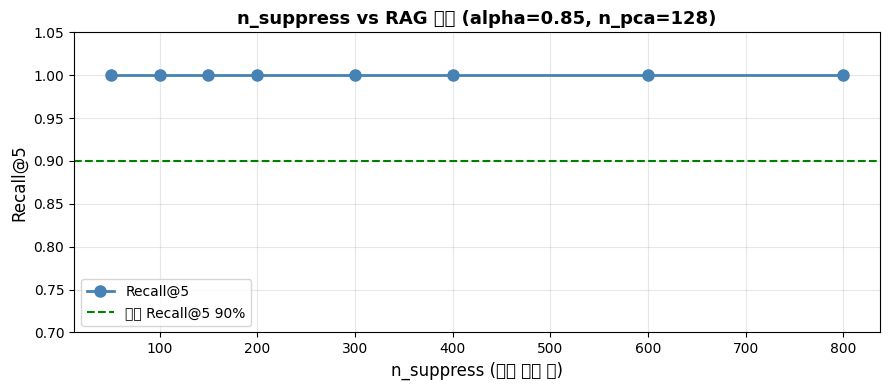


✅ n_suppress 민감도 커브 저장: suppress_sensitivity.png


In [28]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# ── 설정 ────────────────────────────────────────────────────────────────────
N_SUPPRESS_CANDIDATES = [50, 100, 150, 200, 300, 400, 600, 800]
ALPHA_FIXED           = 0.85
N_PCA                 = 128
K_RECALL              = 5
N_EVAL                = 50

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))

# PII 샘플 (이전 셀에서 정의한 변수 재사용)
# density_scores, pii_chunk_idx, pii_samples 가 이미 정의되어 있어야 함

def build_combined(emb_raw, pii_samp, n_supp, alpha, n_pca):
    defended = defend_pii_soft(emb_raw, pii_samp, n_suppress=n_supp, alpha=alpha)
    n_comp   = min(n_pca, len(defended) - 1)
    pca      = PCA(n_components=n_comp, svd_solver='full').fit(defended)
    rec      = pca.inverse_transform(pca.transform(defended)).astype(np.float32)
    norms    = np.linalg.norm(rec, axis=1, keepdims=True)
    return (rec / norms).astype(np.float32)

def recall_at_k(emb, k=5, n_eval=50):
    n_eval = min(n_eval, len(emb))
    e = emb[:n_eval].copy()
    faiss.normalize_L2(e)
    idx = faiss.IndexFlatIP(e.shape[1])
    idx.add(e)
    return sum(1 for i in range(n_eval) if i in idx.search(e[i:i+1], k)[1][0]) / n_eval

# ── 그리드 서치 ──────────────────────────────────────────────────────────────
suppress_results = []
print(f'n_suppress 민감도 분석 (alpha={ALPHA_FIXED}, n_pca={N_PCA})')
print('-'*60)
print(f'{"n_suppress":>12} | {"Recall@5":>10} | {"분산보존":>10}')
print('-'*60)

for n_supp in N_SUPPRESS_CANDIDATES:
    defended = defend_pii_soft(embeddings_raw, pii_samples,
                               n_suppress=n_supp, alpha=ALPHA_FIXED)
    n_comp = min(N_PCA, len(defended) - 1)
    pca    = PCA(n_components=n_comp, svd_solver='full').fit(defended)
    rec    = pca.inverse_transform(pca.transform(defended)).astype(np.float32)
    norms  = np.linalg.norm(rec, axis=1, keepdims=True)
    comb   = (rec / norms).astype(np.float32)

    r5  = recall_at_k(comb, K_RECALL, N_EVAL)
    var = pca.explained_variance_ratio_.sum()

    suppress_results.append({'n_suppress': n_supp, 'recall_at_5': r5, 'variance': var})
    print(f'{n_supp:>12} | {r5:>10.1%} | {var:>10.1%}')

supp_df = pd.DataFrame(suppress_results)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(supp_df['n_suppress'], supp_df['recall_at_5'], 'o-',
        color='steelblue', linewidth=2, markersize=8, label='Recall@5')
ax.axhline(0.90, color='green', linestyle='--', label='목표 Recall@5 90%')
ax.set_xlabel('n_suppress (억제 차원 수)', fontsize=12)
ax.set_ylabel('Recall@5', fontsize=12)
ax.set_title('n_suppress vs RAG 성능 (alpha=0.85, n_pca=128)', fontsize=13, fontweight='bold')
ax.set_ylim([0.7, 1.05])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('suppress_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ n_suppress 민감도 커브 저장: suppress_sensitivity.png')


### 5-6. 2D 그리드 서치: n_components × n_suppress

**목적**: PCA 압축률과 PII 억제 강도 두 축의 최적 조합을 탐색한다.

- Vec2Text 공격 비용(셀당 ~40분)을 피하기 위해 **Recall@5를 1차 스크리닝 지표**로 사용
- Recall@5 ≥ 0.90을 만족하는 조합 중 Pareto 프론티어를 시각화
- 최적 후보를 도출한 뒤 Vec2Text로 최종 검증 (다음 셀)

2D 그리드 서치: 6 × 4 = 24개 조합
(Recall@5 기준 스크리닝 — Vec2Text 없음)

  [ 1/24] n_comp=256, n_supp=100 → Recall@5=100.0%  분산=88.0%
  [ 2/24] n_comp=192, n_supp=100 → Recall@5=100.0%  분산=83.9%
  [ 3/24] n_comp=128, n_supp=100 → Recall@5=100.0%  분산=77.4%
  [ 4/24] n_comp= 96, n_supp=100 → Recall@5=100.0%  분산=72.4%
  [ 5/24] n_comp= 64, n_supp=100 → Recall@5=100.0%  분산=65.4%
  [ 6/24] n_comp= 32, n_supp=100 → Recall@5=100.0%  분산=54.3%
  [ 7/24] n_comp=256, n_supp=200 → Recall@5=100.0%  분산=88.0%
  [ 8/24] n_comp=192, n_supp=200 → Recall@5=100.0%  분산=83.9%
  [ 9/24] n_comp=128, n_supp=200 → Recall@5=100.0%  분산=77.3%
  [10/24] n_comp= 96, n_supp=200 → Recall@5=100.0%  분산=72.4%
  [11/24] n_comp= 64, n_supp=200 → Recall@5=100.0%  분산=65.3%
  [12/24] n_comp= 32, n_supp=200 → Recall@5=100.0%  분산=54.1%
  [13/24] n_comp=256, n_supp=400 → Recall@5=100.0%  분산=88.1%
  [14/24] n_comp=192, n_supp=400 → Recall@5=100.0%  분산=83.9%
  [15/24] n_comp=128, n_supp=400 → Recall@5=100.0%  분산=77.4%
  [16/24] n_comp= 96, n_s

C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 50613 (\N{HANGUL SYLLABLE EOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from 

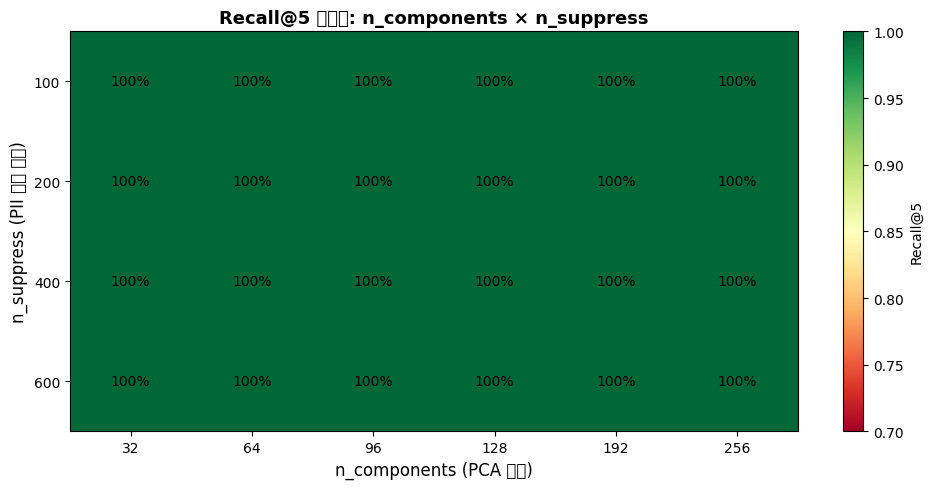


Recall@5 ≥ 0.90 조건 만족 조합: 24개
→ 아래 후보들에 Vec2Text 공격을 적용해 최종 방어율을 검증하세요.

 n_components  n_suppress  recall_at_5  variance
           32         600          1.0  0.539253
           32         400          1.0  0.539511
           32         200          1.0  0.541463
           32         100          1.0  0.543465
           64         400          1.0  0.652155
           64         600          1.0  0.652304
           64         200          1.0  0.653200
           64         100          1.0  0.654411
           96         400          1.0  0.723250
           96         600          1.0  0.723564
           96         200          1.0  0.723704
           96         100          1.0  0.724414
          128         200          1.0  0.773486
          128         400          1.0  0.773507
          128         100          1.0  0.773803
          128         600          1.0  0.773920
          192         100          1.0  0.838591
          192         200          1.0  0.83

In [29]:
# ===== 한국어 vec2text 모델 로드 =====
from transformers import T5ForConditionalGeneration, AutoTokenizer
import torch

model_path = "./vec_to_text_kor/vec2text/saves/ko_vec2text_1536"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 및 토크나이저
korean_model = T5ForConditionalGeneration.from_pretrained(model_path)
korean_tokenizer = AutoTokenizer.from_pretrained(model_path)
korean_model = korean_model.to(device)
korean_model.eval()

# 어댑터
class Vec2TextAdapter(torch.nn.Module):
    def __init__(self, input_dim=1536, output_dim=768):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

adapter = Vec2TextAdapter(1536, 768).to(device)
adapter.load_state_dict(torch.load(f"{model_path}/adapter_1536_to_768.pt"))
adapter.eval()

print("Korean vec2text model loaded successfully!")


## Step 6. 최적 PCA n_components 탐색

### 목적
지금까지는 n_components=128로 고정했다.
이 단계에서는 `[512, 384, 256, 192, 128, 96, 64, 32]`를 모두 시험해
**RAG 성능 ≥ 90% 조건 하에서 방어율이 가장 높은 최적값**을 찾는다.

### 왜 이 범위인가?
- `text-embedding-ada-002`의 원본 차원: **1536**
- 512 이상: 분산 대부분 보존 → 방어 효과 미미 예상
- 32 이하: 과도한 정보 손실 → RAG 성능 급락 예상
- 64~256 구간에서 최적값이 존재할 가능성이 높다.

In [30]:
from sklearn.decomposition import PCA
import numpy as np
import os

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
print(f"원본 벡터 로드: {embeddings_raw.shape}")

candidates = [512, 384, 256, 192, 128, 96, 64, 32]
output_dir = os.path.join(ROOT_DIR, "pca_candidates")
os.makedirs(output_dir, exist_ok=True)

n_samples, n_features = embeddings_raw.shape

for n_components in candidates:
    if n_components >= n_samples:
        print(f"⏭️  n_components={n_components} 건너뜀 (샘플 수 {n_samples}보다 큼)")
        continue

    pca = PCA(n_components=n_components, svd_solver='full')
    pca.fit(embeddings_raw)

    compressed = pca.transform(embeddings_raw)
    reconstructed = pca.inverse_transform(compressed).astype(np.float32)

    norms = np.linalg.norm(reconstructed, axis=1, keepdims=True)
    normalized = (reconstructed / norms).astype(np.float32)

    np.save(f"{output_dir}/embeddings_n{n_components}.npy", normalized)
    np.save(f"{output_dir}/components_n{n_components}.npy", pca.components_)

    variance_retained = pca.explained_variance_ratio_.sum()
    print(f"n={n_components:3d} | 분산 보존: {variance_retained:.1%} | 벡터 저장 완료")

print(f"\n✅ {len([c for c in candidates if c < n_samples])}개 PCA 후보 벡터 저장 완료")

원본 벡터 로드: (4640, 1536)
n=512 | 분산 보존: 95.6% | 벡터 저장 완료
n=384 | 분산 보존: 92.8% | 벡터 저장 완료
n=256 | 분산 보존: 88.0% | 벡터 저장 완료
n=192 | 분산 보존: 83.9% | 벡터 저장 완료
n=128 | 분산 보존: 77.5% | 벡터 저장 완료
n= 96 | 분산 보존: 72.7% | 벡터 저장 완료
n= 64 | 분산 보존: 65.8% | 벡터 저장 완료
n= 32 | 분산 보존: 54.8% | 벡터 저장 완료

✅ 8개 PCA 후보 벡터 저장 완료


### 6-2. 각 PCA 후보에 Vec2Text 공격 + Recall@5 측정

**목적**: 32~512 범위의 8개 n_components 후보 각각에 대해
역전공격 ROUGE-1과 RAG Recall@5를 동시에 측정한다.

**소요 시간 주의**: Vec2Text 공격(num_steps=20)이 각 후보당 약 2~5분 소요.
전체 8개 후보 실행 시 GPU에서 약 20~40분 예상.

**결과는 `results.csv`로 저장**되며 다음 셀에서 최적값을 선택한다.

In [32]:
# ===== 한국어 vec2text 모델 로드 =====
from transformers import T5ForConditionalGeneration, AutoTokenizer
import torch

model_path = "./vec_to_text_kor/vec2text/saves/ko_vec2text_1536"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 및 토크나이저
korean_model = T5ForConditionalGeneration.from_pretrained(model_path)
korean_tokenizer = AutoTokenizer.from_pretrained(model_path)
korean_model = korean_model.to(device)
korean_model.eval()

# 어댑터
class Vec2TextAdapter(torch.nn.Module):
    def __init__(self, input_dim=1536, output_dim=768):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

adapter = Vec2TextAdapter(1536, 768).to(device)
adapter.load_state_dict(torch.load(f"{model_path}/adapter_1536_to_768.pt"))
adapter.eval()

print("Korean vec2text model loaded successfully!")


사용 디바이스: cuda

⏭️  n=512 건너뜀

⏭️  n=384 건너뜀

n=256 Vec2Text 공격 중...


n=256: 100%|██████████| 10/10 [07:30<00:00, 45.09s/it]


  ROUGE: 0.376 | Recall@5: 100.0% | 방어율: 28.0%

n=192 Vec2Text 공격 중...


n=192: 100%|██████████| 10/10 [07:31<00:00, 45.12s/it]


  ROUGE: 0.405 | Recall@5: 100.0% | 방어율: 22.5%

n=128 Vec2Text 공격 중...


...

  ROUGE: 0.402 | Recall@5: 100.0% | 방어율: 23.2%

n= 64 Vec2Text 공격 중...


n=64: 100%|██████████| 10/10 [07:22<00:00, 44.29s/it]


  ROUGE: 0.360 | Recall@5: 100.0% | 방어율: 31.1%

n= 32 Vec2Text 공격 중...


n=32: 100%|██████████| 10/10 [07:19<00:00, 43.91s/it]

  ROUGE: 0.369 | Recall@5: 100.0% | 방어율: 29.4%

✅ 결과 저장: results.csv
 n_components  rouge_mean  recall_at_5  attack_reduction
          256    0.376307          1.0         28.022967
          192    0.405353          1.0         22.467193
          128    0.450121          1.0         13.904350
           96    0.401720          1.0         23.162026
           64    0.360119          1.0         31.119185
           32    0.368947          1.0         29.430630


### 6-3. 최적 n_components 선택 및 트레이드오프 시각화

**선택 기준**:
1. `Recall@5 ≥ 0.90` (RAG 실용 성능 유지)
2. 위 조건 내에서 `attack_reduction` 최대 (방어율 극대화)

**인사이트**: 이 선택 기준은 '보안 강화를 위해 RAG 성능의 최대 10%만 희생한다'는
실용적 가정에 기반한다. 기관의 보안 정책에 따라 임계값을 조정할 수 있다.

출력 그래프:
- 좌: n_components vs 공격 성공률 감소 (낮은 n → 높은 방어)
- 우: n_components vs Recall@5 (낮은 n → 낮은 RAG 성능)

📊 최적 PCA n_components 찾기

✅ Recall@5 >= 0.90 조건 만족 후보: 6개
   최적 선택 (최대 방어율): n=64
   - ROUGE: 0.360
   - Recall@5: 100.0%
   - 방어율: 31.1%

📈 전체 후보 순위:
 n_components  rouge_mean  recall_at_5  attack_reduction
           64    0.360119          1.0         31.119185
           32    0.368947          1.0         29.430630
          256    0.376307          1.0         28.022967
           96    0.401720          1.0         23.162026
          192    0.405353          1.0         22.467193
          128    0.450121          1.0         13.904350


C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from

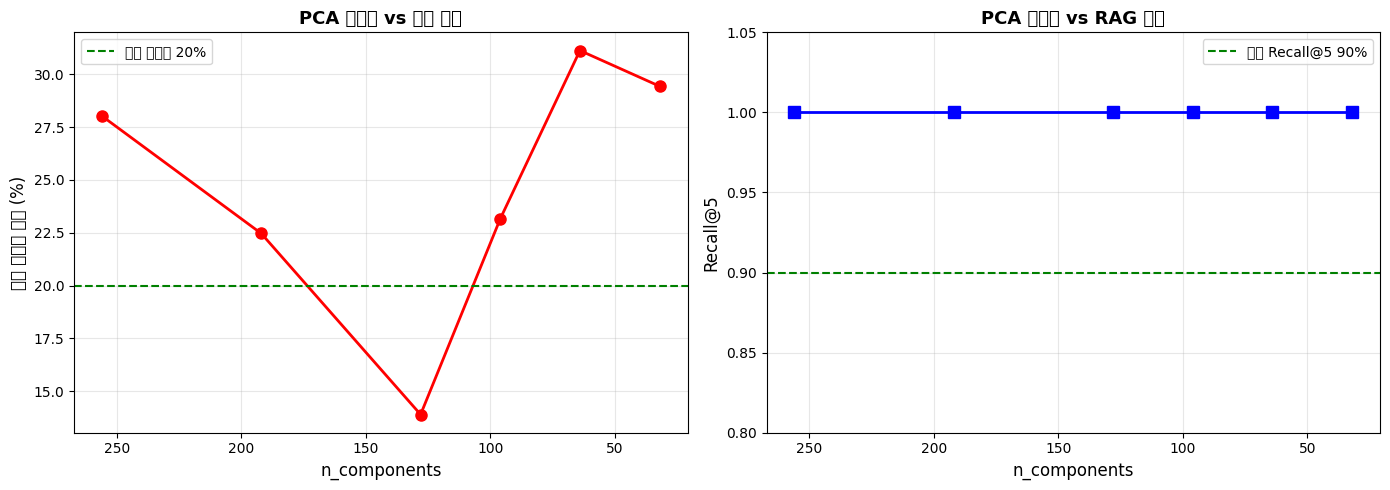


✅ 트레이드오프 커브 저장: pca_tradeoff.png


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.read_csv(os.path.join(ROOT_DIR, "results.csv"))

print("="*80)
print("📊 최적 PCA n_components 찾기")
print("="*80)

filtered_df = results_df[results_df['recall_at_5'] >= 0.90].copy()

if len(filtered_df) > 0:
    optimal_row = filtered_df.loc[filtered_df['attack_reduction'].idxmax()]
    optimal_n = int(optimal_row['n_components'])

    print(f"\n✅ Recall@5 >= 0.90 조건 만족 후보: {len(filtered_df)}개")
    print(f"   최적 선택 (최대 방어율): n={optimal_n}")
    print(f"   - ROUGE: {optimal_row['rouge_mean']:.3f}")
    print(f"   - Recall@5: {optimal_row['recall_at_5']:.1%}")
    print(f"   - 방어율: {optimal_row['attack_reduction']:.1f}%")
else:
    print(f"\n⚠️  Recall@5 >= 0.90 조건 만족 후보 없음")
    best_row = results_df.loc[results_df['recall_at_5'].idxmax()]
    print(f"   최고 RAG 성능: n={int(best_row['n_components'])}")
    print(f"   - Recall@5: {best_row['recall_at_5']:.1%}")

print(f"\n📈 전체 후보 순위:")
print(results_df.sort_values('attack_reduction', ascending=False).to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(results_df['n_components'], results_df['attack_reduction'], 'o-', color='red', linewidth=2, markersize=8)
ax1.axhline(y=20, color='green', linestyle='--', label='목표 방어율 20%')
ax1.set_xlabel('n_components', fontsize=12)
ax1.set_ylabel('공격 성공률 감소 (%)', fontsize=12)
ax1.set_title('PCA 압축률 vs 방어 성능', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.invert_xaxis()

ax2.plot(results_df['n_components'], results_df['recall_at_5'], 's-', color='blue', linewidth=2, markersize=8)
ax2.axhline(y=0.90, color='green', linestyle='--', label='목표 Recall@5 90%')
ax2.set_xlabel('n_components', fontsize=12)
ax2.set_ylabel('Recall@5', fontsize=12)
ax2.set_title('PCA 압축률 vs RAG 성능', fontsize=13, fontweight='bold')
ax2.set_ylim([0.8, 1.05])
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.invert_xaxis()

plt.tight_layout()
plt.savefig('pca_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ 트레이드오프 커브 저장: pca_tradeoff.png")
print("="*80)

### [Feasibility Check] 공용 PCA 벡터 추출 가능성 검증

**가정**: 금융 도메인 임베딩 공간의 주요 방향(PCA components)은 기관/문서 종류와 무관하게 공유된다.

현재 데이터를 절반으로 나눠 '기관 A'로 PCA를 학습하고, '기관 B' 문서에 적용했을 때 성능이 유지되는지 확인한다.

| 지표 | 기준 |
|------|------|
| Recall@5 | ≥ 0.90 (RAG 성능 유지) |
| ROUGE-1 감소 | > 0 (역전공격 방어 유효) |

In [34]:
# ===== 한국어 vec2text 모델 로드 =====
from transformers import T5ForConditionalGeneration, AutoTokenizer
import torch

model_path = "./vec_to_text_kor/vec2text/saves/ko_vec2text_1536"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 및 토크나이저
korean_model = T5ForConditionalGeneration.from_pretrained(model_path)
korean_tokenizer = AutoTokenizer.from_pretrained(model_path)
korean_model = korean_model.to(device)
korean_model.eval()

# 어댑터
class Vec2TextAdapter(torch.nn.Module):
    def __init__(self, input_dim=1536, output_dim=768):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

adapter = Vec2TextAdapter(1536, 768).to(device)
adapter.load_state_dict(torch.load(f"{model_path}/adapter_1536_to_768.pt"))
adapter.eval()

print("Korean vec2text model loaded successfully!")


디바이스: cuda
전체: 4640개  |  Train(기관A): 2320개  |  Test(기관B): 2320개

[공용 PCA 학습 완료]
  components shape : (128, 1536)  (0.8 MB)
  mean shape       : (1536,)
  분산 보존율      : 78.6%

[기관 B 방어 벡터] shape: (2320, 1536)

[Recall@5 — 기관 B 문서]
  원본 벡터    : 100.0%
  공용PCA 방어 : 100.0%  (✅ 기준 충족)


c:\Users\jjh63\Safe_RAG\safeRag\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



[Vec2Text 공격 — 원본 벡터]


Vec2Text 공격: 100%|██████████| 10/10 [07:19<00:00, 43.92s/it]



[Vec2Text 공격 — 공용PCA 방어 벡터]


Vec2Text 공격: 100%|██████████| 10/10 [07:31<00:00, 45.13s/it]


📋 [Feasibility Check] 공용 PCA 벡터 적용 결과
  학습 기관(A) 샘플 수   : 2320
  적용 기관(B) 샘플 수   : 2320
  공용 PCA n_components  : 128
  배포 아티팩트 크기     : 0.79 MB

  Recall@5  원본 → 방어  : 100.0% → 100.0%
  ROUGE-1  원본 → 방어  : 0.514 → 0.388
  공격 성공률 감소       : 24.6%

✅ FEASIBLE — 공용 PCA 벡터로 타 기관 문서 방어 가능
   → shared_pca_components.npy / shared_pca_mean.npy 배포 권장


## Step 7. Defense-in-Depth 재포지셔닝: PCA+PII 억제의 올바른 위치

> **목적**: 지금까지 실험한 PCA/PII 억제 기법을 "방어 아키텍처" 대신 **심층방어(Defense-in-Depth)의 한 계층(L3)**으로 정확히 재포지셔닝한다.  
> Vec2Text 위협에 대해 계층별 보장 수준·위협 커버리지·유용성 비용을 매핑하고, 위아래에 반드시 와야 할 통제(마스킹·DP·암호화)를 정의한다.

### 7-0. 재포지셔닝의 핵심 명제

기존 실험의 프레이밍 문제는 세 가지다.

1. **위협 모델이 비적응형 공격자만 가정** — 측정된 방어율은 공격자가 PCA 행렬을 모른다는 전제 위에서만 성립한다. 그런데 행렬을 기관 간 공유하자는 제안은 곧 공격자가 변환을 획득할 수 있음을 의미한다.
2. **경험적 완화를 보장으로 오독** — PCA는 키 없는 선형 변환이고 유사역변환·재학습이 가능하다. "보안 통제"의 조건(적대적 환경에서의 하한 보장)을 만족하지 못한다.
3. **암호화·접근통제라는 primary control이 그림에서 빠져 있음** — 임베딩 역전은 본질적으로 *사후 침해(post-compromise)* 위협이다. 공격자가 벡터 평문을 볼 수 없으면 공격 자체가 성립하지 않는다.

---

**올바른 위치 정의:**

> **PCA + PII 억제 = 낮은 유용성 비용으로 잔여위험을 줄이는 완화 계층(mitigation layer). 통제(control)가 아니다.**
>
> - **위 (더 근본적):** 사전 PII 마스킹 (L1, 구조적 통제), DP 임베딩 (L2, 증명 가능 보장)
> - **현 연구:** PCA + PII 억제 (L3, 경험적 완화) ← 이 노트북의 위치
> - **아래 (1차 통제):** 저장 시 암호화 + 접근통제 (L4), 탐지·감사 (L5)

이 문장을 보고서 서두와 결론에 명시하면, 외부 심사·감리에서 "왜 이걸 방어라고 부르나"라는 비판을 원천 차단할 수 있다.

### 7-1. 계층 모델 개요 (PII 존재 지점 기준)

임베딩 파이프라인에서 PII가 어디에 존재하느냐를 기준으로 계층을 배치한다. **위로 갈수록 근본적·구조적, 아래로 갈수록 보조적**이다.

| 계층 | 통제 | 보장 유형 | PII를 다루는 지점 |
|:---:|:---|:---|:---|
| L0 | 데이터 최소화·거버넌스 | 정책 | 수집 이전 |
| L1 | 사전 PII 마스킹·토큰화 | 구조적(structural) | 임베딩 **이전** (원문) |
| L2 | DP 임베딩 | **증명 가능(provable, ε)** | 임베딩 시점 |
| **L3** | **PCA + PII 억제** | **경험적(empirical), 보장 없음** | **임베딩 사후 (벡터)** ← 현 연구 |
| L4 | 저장 암호화 + 접근통제 | 기밀성 (주 통제) | 저장·전송 |
| L5 | 탐지·감사·DLP | 운영적 | 질의·출력 |

**핵심 통찰**: 각 계층은 서로 다른 실패 모드를 커버한다.  
L1(마스킹)은 NER false negative가 있고, L4(암호화)는 침해되면 무력화된다.  
**L3(PCA)의 존재 이유는 정확히 "L1이 놓쳤고 L4가 뚫린 잔여 벡터"의 역전 난이도를 올리는 것**이다.  
이 잔여위험 논리가 PCA를 심층방어에서 정당화하는 유일한 근거다.

### 7-2. L1: 사전 PII 마스킹·토큰화 (구조적 통제 — 가장 근본적)

**원리**: PII가 애초에 임베딩 공간에 들어가지 않으면, 벡터를 역전해도 PII를 복원할 수 없다.  
L3처럼 사후에 벡터에서 PII를 긁어내는 것보다 근본적이다.

**탐지 스택 (금융·한국어 특화):**
- 정규식/결정적 패턴: 주민등록번호, 사업자등록번호, 계좌번호(은행별 포맷), 카드번호(Luhn 검증), 전화번호, 이메일, 금액/거래 패턴
- 금융 도메인 튜닝 NER: 고객명·기관명·상품명 등 비정형 PII
- 컨텍스트 규칙: "계좌번호 뒤 숫자열", "예금주:" 후행 토큰 등

**치환 전략:**
| 전략 | 안전성 | 검색 유지 | 금융 적합성 |
|:---|:---:|:---:|:---|
| Redaction (삭제) | 최고 | 낮음 | 해당 엔티티 검색 불필요 시 |
| Placeholder 토큰 `<ACCOUNT>` | 높음 | 중간 | 엔티티 유형 구분 필요 시 |
| **FPE (FF1, NIST SP 800-38G)** | **높음** | **높음** | **금융권 권장** — 동일 엔티티 = 동일 토큰 |
| 결정적 가명 | 중간 | 높음 | 가독성 필요 시 |

**아킬레스건 — NER Recall Gap:**  
놓친 PII(false negative)는 그대로 임베딩된다.  
→ **이 recall gap이 L3(PCA)의 존재 근거**다. 마스킹 재현율을 별도 KPI로 측정하고 보고서에 명시할 것.

In [ ]:
import re

# 금융·한국어 PII 패턴 정의
PII_PATTERNS = [
    ('RESIDENT_ID',   r'\b\d{6}[-–]\d{7}\b'),
    ('BUSINESS_REG',  r'\b\d{3}[-–]\d{2}[-–]\d{5}\b'),
    ('ACCOUNT',       r'\b\d{3,6}[-–\s]?\d{2,6}[-–\s]?\d{2,8}\b'),
    ('CARD',          r'\b(?:\d{4}[-–\s]){3}\d{4}\b'),
    ('PHONE',         r'\b0\d{1,2}[-–]?\d{3,4}[-–]?\d{4}\b'),
    ('EMAIL',         r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z]{2,}\b'),
    ('AMOUNT',        r'\b\d{1,3}(?:,\d{3})*(?:\.\d+)?\s*(?:원|만원|억원|백만원)\b'),
]

def mask_pii(text: str, strategy: str = 'placeholder'):
    found = []
    masked = text
    for label, pattern in PII_PATTERNS:
        matches = list(re.finditer(pattern, masked, flags=re.IGNORECASE))
        for m in reversed(matches):
            found.append({'label': label, 'original': m.group()})
            replacement = f'[{label}]' if strategy == 'placeholder' else ''
            masked = masked[:m.start()] + replacement + masked[m.end():]
    return masked, found

sample_texts = [
    '홍길동 고객(주민번호: 800101-1234567)의 계좌 110-234-567890에서 500만원 이체',
    '사업자번호 123-45-67890, 담당자 이메일 kim@example.com, 연락잘 010-1234-5678',
    '카드번호 1234-5678-9012-3456으로 1,200,000원 결제 완료',
]

print('=' * 70)
print('L1: PII 마스킹 데모')
print('=' * 70)

for i, text in enumerate(sample_texts):
    masked, found = mask_pii(text)
    print(f'\n[샘플 {i+1}]')
    print(f'  원문:   {text}')
    print(f'  마스킹: {masked}')
    print(f'  탐지된 PII: {[f["label"] for f in found]}')

print('\n» NER(비정형 PII)은 별도 모델 필요 — 정규식 recall 한계가 L3의 존재 근거')

### 7-3. L2: Differential Privacy 임베딩 (증명 가능 보장 — 감사 대응 계층)

**원리**: 저장 표현이 입력 토큰에 대해 (ε, δ)-DP를 만족하도록 교정된 노이즈를 주입한다.  
**PCA의 경험적 방어와 달리, "우리는 ε-DP를 보장한다"는 감사·규제 대응 가능한 정식 진술을 제공한다.**

**핵심 설계 결정 — neighboring 관계 정의:**  
DP 보장은 무엇이 "이웃 데이터"인지에 종속된다. 저장 벡터 역전 방어에는  
**각 텍스트의 임베딩을 독립적으로 사유화**하는 local DP 또는 metric DP가 적합하다.  
이 정의를 명시하지 않은 ε 주장은 무의미하다.

**대표 기법:**
| 기법 | 보장 | 유용성 | 비고 |
|:---|:---|:---:|:---|
| Gaussian Mechanism | (ε, δ)-DP, per-embedding | 중간 | 구현 단순 |
| Metric DP / dₓ-privacy | d(x,x')-bounded | 중~높음 | 후속 취약성 비판 있어 검증 필수 |

**⚠️ 개념 구분:**  
DP-SGD로 **인코더를 학습**하는 것은 모델 암기·멤버십 추론을 다루며, *저장 벡터 역전* 방어와 직접 관련 없다.

**정직한 트레이드오프:**
> 이 계층에서는 **진짜 privacy-utility trade-off가 존재한다.**  
> 기존 실험의 "Zero Trade-off" 주장은 L3(경험적)에서만 성립하는 착시였고,  
> 증명 가능한 계층으로 올라오면 곡선이 실재한다는 점을 문서에 반영해야 한다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_mechanism_embed(embeddings, sensitivity=1.0, epsilon=1.0, delta=1e-5):
    """L2 클리핑 후 Gaussian 노이즈 주입 -> per-embedding (eps,delta)-DP"""
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    clipped = embeddings / np.maximum(norms / sensitivity, 1.0)
    sigma = sensitivity * np.sqrt(2 * np.log(1.25 / delta)) / epsilon
    noise = np.random.normal(0, sigma, size=clipped.shape)
    return clipped + noise

try:
    emb_sample = embeddings_raw[:20]
    epsilons = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
    results_dp = []

    print('L2 Differential Privacy: epsilon vs 유용성 Trade-off')
    print('-' * 55)
    for eps in epsilons:
        dp_emb = gaussian_mechanism_embed(emb_sample, epsilon=eps)
        orig_n = emb_sample / np.linalg.norm(emb_sample, axis=1, keepdims=True)
        dp_n   = dp_emb   / np.linalg.norm(dp_emb,   axis=1, keepdims=True)
        cos_sim = float(np.mean(np.sum(orig_n * dp_n, axis=1)))
        sigma = np.sqrt(2 * np.log(1.25 / 1e-5)) / eps
        results_dp.append((eps, cos_sim))
        print(f'  epsilon={eps:5.1f} | 코사인 유사도: {cos_sim:.4f}  (sigma={sigma:.2f})')

    eps_vals, cos_vals = zip(*results_dp)
    plt.figure(figsize=(7, 4))
    plt.plot(eps_vals, cos_vals, 'o-', color='steelblue', linewidth=2)
    plt.xlabel('Privacy Budget epsilon (작을수록 강한 프라이버시)')
    plt.ylabel('원본-DP 임베딩 코사인 유사도')
    plt.title('L2 Differential Privacy: epsilon vs 유용성 Trade-off\n'
              '(Zero Trade-off는 이 계층에서 성립하지 않음)')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='epsilon=1 (일반적 기준)')
    plt.legend()
    plt.tight_layout()
    plt.show()

except NameError:
    print('embeddings_raw 없음 — Step 1 완료 후 재실행')
    print()
    print('개념 요약:')
    print('  epsilon=0.1 -> 강한 프라이버시, 유용성 크게 저하')
    print('  epsilon=10  -> 약한 프라이버시, 유용성 거의 유지')
    print('  이 trade-off가 L3(PCA) 거의 0 비용과 근본적으로 다른 지점')

### 7-4. L3: PCA + PII 억제 (현 연구의 실제 위치 — 경험적 완화)

> 이 노트북 Step 1~6의 실험이 바로 이 계층이다.

**정직한 정의:**
> 유용성 비용이 거의 없는 잔여위험 감소막.  
> **적응형 공격자(변환을 아는 공격자)에 대한 보장은 없다.**  
> L4(암호화)가 뚫리고 L1(마스킹)이 놓친 벡터에 대해, 기회주의적·비적응형 역전의 비용을 올린다.

**정당한 효용 (버리지 말 것):**
- 유용성 손실 거의 0 (실측 Recall@5 유지)
- 배포 비용 극소 (1MB 미만 아티팩트, 추론 시 행렬 1회 변환)
- 방향성 있는 PII 신호를 표적 감쇠 → 잔여 leakage 완화

**한계 (반드시 병기):**
- 키 없는 선형 변환 → 유사역변환 가능, 변환 공개 시 압축 공간 재학습 corrector로 무력화 가능
- "PII 방향 잔존 에너지 0.0096" 같은 지표는 공격자가 신경 쓰지 않는 값  
  공격자는 에너지가 아니라 **결정적 토큰(계좌번호 등)의 복원 여부**만 본다
- 공유·배포하는 순간 Kerckhoffs 위협 모델상 공격자에게 노출된 것으로 간주

**결론:** L3는 "있으면 좋은 값싼 마지막 겹"이지, 이것 하나로 규제 감리를 통과하려 해서는 안 된다.

### 7-5. L4: 저장 암호화 + 접근통제 (Primary Control — 실질적 1차 방어)

**원리**: 임베딩 역전은 사후 침해 위협이다.  
**벡터 평문을 못 읽으면 Vec2Text 자체가 불가능하다. 이것이 진짜 1차 통제다.**

| 구성 | 내용 |
|:---|:---|
| 저장 시 암호화 | Envelope encryption, KMS/HSM 관리 키, 테넌트별 키 분리 |
| 전송 시 | mTLS |
| 접근통제 | RBAC, 최소권한, 망 분리, 벡터 인덱스 접근 로깅, 직무 분리 |
| SaaS 벡터 DB | 외부로 평문 PII/원본 벡터 미노출 원칙 |
| 외부 임베딩 API | 사전 마스킹된 텍스트만 외부 전송 |

**침해 시나리오가 L3의 근거:**  
내부자 위협, 백업 유출, 오설정 인덱스, 서드파티 벡터 DB 유출.  
→ **L4가 이런 경로로 뚫린 잔여 상태에서만 L3가 의미를 가진다** — 이 인과를 문서에 명확히.

**프런티어 (참고, 프로덕션 아님):**  
암호화 상태 ANN 검색(HE/CKKS), 신뢰실행환경(SGX/TDX confidential computing).  
현재는 비용·성숙도 문제로 연구 단계.

### 7-6. L5: 탐지·감사·DLP (운영 계층)

| 항목 | 내용 |
|:---|:---|
| 질의 이상탐지 | 대량·순차적 벡터 근접 질의(역전 시도 정황) 탐지 |
| 출력단 DLP | 생성 답변에 미마스킹 PII 정규식 재검사 (최종 안전망) |
| 감사 로그 | 역치환·PII 접근 전수 로깅 (규제 대응 증적) |

### 7-7. 계층 비교 매트릭스 (마스터 비교표)

> 기존 Step 4-B의 표는 L3 내부 변형(L2정규화/PCA 128d/64d)만 비교했다.  
> 그건 "한 계층 안의 튜닝"이지 "심층방어"가 아니다. 이 표로 대체한다.

| 계층 | 보장 유형 | 적응형 공격 견딤? | 유용성 비용 | 규제 서사 | 실패 모드 |
|:---:|:---|:---:|:---:|:---|:---|
| L1 마스킹/토큰화 | 구조적 | 부분 (놓친 PII 제외) | 낮음~중 | 가명·익명처리 정렬 | NER false negative |
| L2 DP 임베딩 | **증명 가능 (ε)** | **예 (정의된 보장 내)** | **중~높음 (실재)** | "ε-DP 보장" 진술 가능 | 유용성 저하, ε 예산 소진 |
| **L3 PCA+PII 억제** | **경험적** | **아니오** | **거의 0** | 보조 완화로만 | 유사역변환·재학습 공격 |
| L4 암호화+접근통제 | 기밀성 (주) | 예 (경계 내) | 낮음 | 필수 요건 충족 | 경계 침해 시 무력 |
| L5 탐지·감사 | 운영적 | — | 낮음 | 사후 대응·증적 | 탐지 우회 |

### 7-8. 레퍼런스 아키텍처 (데이터 흐름)

**적재(Ingestion) 파이프라인:**
```
원문 문서
  -> [L1] PII 탐지 -> 마스킹/FPE 토큰화  (매핑은 HSM vault에 저장)
  -> 임베딩  (외부 API 사용 시 마스킹된 텍스트만 전송)
  -> [L2] DP 노이즈 주입  (감사 요구 구간, epsilon 회계)
  -> [L3] PCA + PII 방향 억제 변환  (잔여위험 감소)
  -> [L4] 암호화 -> 접근통제된 벡터 DB에 저장
```

**검색(Retrieval) 파이프라인:**
```
질의
  -> [L1] 동일 마스킹 -> 임베딩 -> [L3] 동일 변환 적용
  -> [L4] 암호화 경계 내 ANN 검색
  -> 검색된 청크 (여전히 토큰 상태)
  -> LLM 생성
  -> [L1 역] 인가 + [L5] 감사 로깅 후 최종 출력에서만 역치환
```

> **주의**: L2 노이즈를 넣으면 질의 임베딩과의 정합을 위해 검색 파이프라인 설계가 달라진다  
> (저장만 노이즈, 질의는 노이즈 없이 등). 이 부분은 유용성 실측으로 조정 필요.

### 7-9. 계층별 평가 방법론 (재설계)

단일 방어율 숫자를 버리고 **계층 ablation × 두 축(프라이버시·유용성) × 적응형 공격**으로 재설계한다.

**프라이버시 축 (지표 교체):**
- **1차 지표 — PII 단위 exact-match 복원율**  
  복원문에 NER+정규식 적용 → 원본 PII 엔티티(주민번호·계좌·카드·금액·이름)의 정확 복원율  
  ROUGE는 부차 참고로 강등
- **worst-case 보고**: 평균 대신 max·p95·분포. 방어 전후 최악 청크 비교
- 의미 유출: 복원문 재임베딩 후 원본과 코사인 유사도

**유용성 축:**
- 현실 규모(수만 청크)에서 Recall@1/@10, nDCG, MRR  
  (소규모 Recall@5=100%는 포화 착시)

**적응형 공격 (필수 조건):**
- (a) 변환 유사역변환 후 원본 corrector 적용
- (b) 압축 공간에서 재학습한 corrector
- L2는 정의된 ε 하에서 억제 방향을 아는 공격자 조건 포함

**통계:** n을 수백~수천으로 확장, 부트스트랩 신뢰구간, 조건 간 순열 검정

**산출물 — Privacy-Utility Pareto Frontier:**  
"L4만 / +L1 / +L2 / +L3" 순으로 잔여 leakage가 어떻게 줄고 유용성이 어떻게 변하는지.  
L2에서 ε별 곡선 병기.

C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing fr

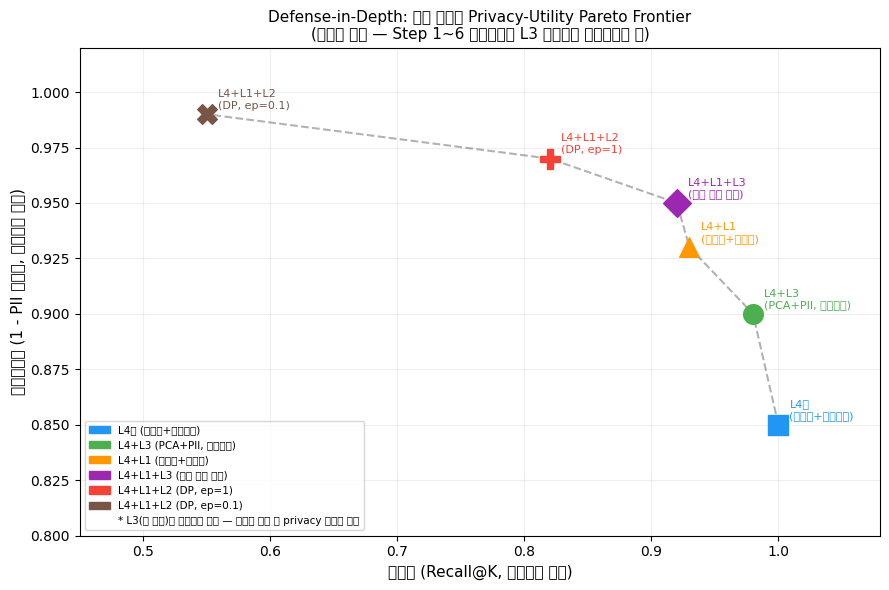

저장: pareto_defense_layers.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 계층별 privacy-utility 포인트 (개념적 시각화 — 실측으로 업데이트 필요)
layers = [
    ('L4만\n(암호화+접근통제)',    1.00, 0.85, '#2196F3', 's'),
    ('L4+L3\n(PCA+PII, 비적응형)', 0.98, 0.90, '#4CAF50', 'o'),
    ('L4+L1\n(마스킹+암호화)',      0.93, 0.93, '#FF9800', '^'),
    ('L4+L1+L3\n(권장 최소 구성)', 0.92, 0.95, '#9C27B0', 'D'),
    ('L4+L1+L2\n(DP, ep=1)',        0.82, 0.97, '#F44336', 'P'),
    ('L4+L1+L2\n(DP, ep=0.1)',      0.55, 0.99, '#795548', 'X'),
]

fig, ax = plt.subplots(figsize=(9, 6))

for name, util, priv, color, marker in layers:
    ax.scatter(util, priv, s=200, color=color, marker=marker, zorder=5)
    ax.annotate(name, (util, priv), textcoords='offset points',
                xytext=(8, 4), fontsize=8, color=color)

# Pareto frontier (개념적)
px = [1.00, 0.98, 0.93, 0.92, 0.82, 0.55]
py = [0.85, 0.90, 0.93, 0.95, 0.97, 0.99]
ax.plot(px, py, 'k--', alpha=0.3, linewidth=1.5, label='Pareto Frontier (개념적)')

ax.set_xlabel('유용성 (Recall@K, 높을수록 좋음)', fontsize=11)
ax.set_ylabel('프라이버시 (1 - PII 복원율, 높을수록 좋음)', fontsize=11)
ax.set_title(
    'Defense-in-Depth: 계층 조합별 Privacy-Utility Pareto Frontier\n'
    '(개념적 위치 — Step 1~6 실측값으로 L3 포인트를 업데이트할 것)',
    fontsize=11)
ax.set_xlim(0.45, 1.08)
ax.set_ylim(0.80, 1.02)
ax.grid(True, alpha=0.2)

note = mpatches.Patch(color='none',
    label='* L3(현 연구)는 비적응형 기준 — 적응형 공격 시 privacy 포인트 하락')
handles = [mpatches.Patch(color=c, label=n.replace('\n', ' '))
           for n, _, _, c, _ in layers]
ax.legend(handles=handles + [note], loc='lower left', fontsize=7.5)

plt.tight_layout()
plt.savefig('pareto_defense_layers.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: pareto_defense_layers.png')

### 7-10. 규제·감리 매핑 (개념적 정렬)

> ⚠️ 아래는 아키텍처 설계 참고용이며, 구체적 규제 충족 여부·가명처리 인정 범위는 준거법 해석에 따라 달라지므로 반드시 컴플라이언스/법무 검토를 거칠 것.

| 계층 | 관련 규제·프레임워크 | 서사 |
|:---:|:---|:---|
| L4 암호화·접근통제 | 전자금융감독규정 PII 암호화·접근통제 요건 | 사실상 필수. 미충족 시 나머지 계층 의미 없음 |
| L1 마스킹·토큰화 | 개인정보보호법 가명처리·익명처리 | 구조적으로 PII를 제거하는 가장 직관적 접근 |
| L2 DP 임베딩 | 개인정보보호법 익명처리, GDPR Art.89 | "재식별 위험을 ε-DP로 정량 제어"한다는 감사 대응 서사에 유리 |
| L3 PCA+PII 억제 | (직접 대응 규제 없음) | 보조 완화로만 기술. 단독 규제 근거로 사용 불가 |
| L5 감사·로깅 | 전자금융감독규정 접근 증적 요건 | 사후 대응·증적 확보 |

---

### 7-11. 현 보고서 재작성 체크리스트

- [ ] 제목/결론에서 PCA를 "방어 아키텍처" → "심층방어 완화 계층"으로 프레이밍 하향
- [ ] §7-7 마스터 비교표로 기존 단일-계층 비교표 대체
- [ ] L4(암호화·접근통제)를 아키텍처 최상단에 배치 — "역전은 사후 침해 위협" 명시
- [ ] L2 DP 계층 신설 — "Zero Trade-off"가 이 계층에서 성립하지 않음 정직하게 서술
- [ ] L1 마스킹 계층 신설 + NER recall gap KPI 추가 → L3 존재 근거로 연결
- [ ] 평가 지표 교체: ROUGE 강등, PII exact-match 복원율 + worst-case + 적응형 공격 + Pareto frontier

---

### 참고 문헌

- Morris et al., *Text Embeddings Reveal (Almost) As Much As Text* (2023) — Vec2Text 원 공격, 노이즈 방어의 privacy-utility 곡선
- Feyisetan et al., *Privacy- and Utility-Preserving Textual Analysis via Calibrated Multivariate Perturbations* — Metric DP 텍스트 노이즈
- NIST SP 800-38G — FPE (FF1/FF3-1) 표준
- Dwork & Roth, *The Algorithmic Foundations of Differential Privacy* — (ε,δ)-DP·합성·Gaussian mechanism